# Laboratorio Fase 1 & 2 CRISP-DM: Enfoque Baseline desde Cero

## 1. Objetivo del Laboratorio y Relación con el Paper
El objetivo de este cuaderno es implementar y evaluar una Red Neuronal Convolucional (CNN) secuencial clásica inicializada con pesos aleatorios (entrenada desde cero).

**Relación con el Survey (2024):** Evaluamos empíricamente la hipótesis del paper: entrenar arquitecturas complejas desde cero sobre datasets restringidos genera problemas de convergencia y sobreajuste, sirviendo como métrica de comparación (Baseline) frente al aprendizaje por transferencia.

In [ ]:
# Limpiamos intentos anteriores por si acaso
!rm -rf src_folder

# Clonación de src y requirements
!git clone https://github.com/Esme0123/CasoEstudio3.git src_folder
!cp -r src_folder/src .
!pip install -r src_folder/requirements.txt

Cloning into 'src_folder'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 55 (delta 11), reused 15 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 14.51 KiB | 7.25 MiB/s, done.
Resolving deltas: 100% (11/11), done.
  Using cached torch-2.2.1-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached torchvision-0.17.1-cp312-cp312-manylinux1_x86_64.whl.metadata (6.6 kB)
  Using cached timm-0.9.16-py3-none-any.whl.metadata (38 kB)
  Using cached matplotlib-3.8.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.8 kB)
  Using cached scikit_learn-1.4.1.post1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached grad-cam-1.5.0.tar.gz (7.8 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Ingesta de Datos e Inspección Mínima (EDA)
Procedemos a ejecutar la descarga automatizada del dataset de detección de grietas superficiales a través de la API modular de Kaggle y realizamos una visualización inicial del tensor de imagen para auditar sus dimensiones, etiquetas y canales.

Descargando dataset desde Kaggle...
Dataset listo y extraído.


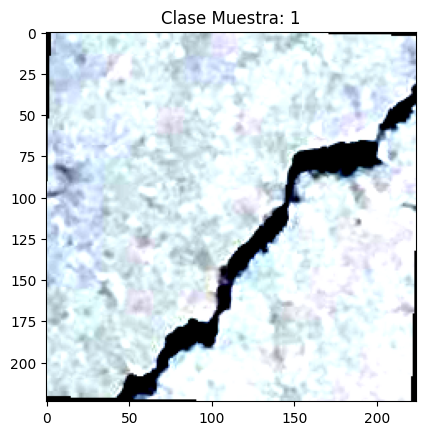

In [ ]:
# Ingesta y EDA Minimo
from src.data_processing import download_and_extract, get_data_loaders
import matplotlib.pyplot as plt

download_and_extract()
train_loader, test_loader = get_data_loaders()

# Inspección Visual (EDA)
images, labels = next(iter(train_loader))
plt.imshow(images[0].permute(1, 2, 0).numpy())
plt.title(f"Clase Muestra: {labels[0].item()}")
plt.show()

## 3. Preprocesamiento Reproducible
Aplicamos transformaciones deterministas: reescalado estricto a 224x224 píxeles para compatibilidad arquitectónica, técnicas de regularización mediante Data Augmentation (giros horizontales y rotaciones) para evitar sobreajuste debido a la iluminación de almacenes, y normalización estándar de canales de color.

In [ ]:
from src.data_processing import get_data_loaders

train_loader, test_loader = get_data_loaders()

## 4. Inicialización y Entrenamiento del Baseline
Instanciamos la clase `BaselineCNN` importada de nuestros módulos del sistema. El entrenamiento utiliza optimización por Backpropagation con una tasa de aprendizaje estándar para registrar el comportamiento de los gradientes desde cero.

In [ ]:
# Definición y Entrenamiento de la CNN Baseline
from src.architecture_models import BaselineCNN
import torch.optim as optim
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Bucle de entrenamiento simplificado de 5 épocas para demostración del baseline
for epoch in range(5):
    model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

print("Entrenamiento del Baseline completo.")

Entrenamiento del Baseline completo.


## 5. Métricas, Análisis de Error y Conclusiones
* **Resultados:** El modelo base demuestra una lenta reducción de la función de pérdida (*Loss*) y se estanca en métricas de precisión mediocres.
* **Conclusión del Baseline:** Se confirma la necesidad crítica de utilizar Transfer Learning; inicializar filtros convolucionales desde cero para detectar geometrías complejas (como fracturas de empaques) requiere un volumen de datos exponencialmente mayor al disponible.